**Using synthetic data generated by Claude, I wanted to test run what a forecasting experience looks like for Norfolk Southern**

*Examine the generated data*

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv('ns_locomotive_sensors.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [2]:
#look at the hour index
df['hour'] = df.groupby('locomotive_id').cumcount()
print(f"Shape of the dataframe: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Locomotive IDs: {df['locomotive_id'].unique()}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Hours per locomotive: {df['hour'].max() + 1}")

Shape of the dataframe: 36000 rows and 13 columns
Locomotive IDs: ['NS-1001' 'NS-1002' 'NS-1003' 'NS-1004' 'NS-1005' 'NS-1006' 'NS-1007'
 'NS-1008' 'NS-1009' 'NS-1010' 'NS-1011' 'NS-1012' 'NS-1013' 'NS-1014'
 'NS-1015' 'NS-1016' 'NS-1017' 'NS-1018' 'NS-1019' 'NS-1020' 'NS-1021'
 'NS-1022' 'NS-1023' 'NS-1024' 'NS-1025' 'NS-1026' 'NS-1027' 'NS-1028'
 'NS-1029' 'NS-1030' 'NS-1031' 'NS-1032' 'NS-1033' 'NS-1034' 'NS-1035'
 'NS-1036' 'NS-1037' 'NS-1038' 'NS-1039' 'NS-1040' 'NS-1041' 'NS-1042'
 'NS-1043' 'NS-1044' 'NS-1045' 'NS-1046' 'NS-1047' 'NS-1048' 'NS-1049'
 'NS-1050']
Date range: 2026-01-01 to 2026-01-30
Hours per locomotive: 720


In [5]:
df.head(10)

,timestamp,locomotive_id,failure_type_true,coolant_temp_f,coolant_level_pct,battery_volts,oil_pressure_psi,engine_temp_f,rpm,ambient_temp_f,cooling_water_loss,battery_failure,hour
0,2026-01-01 00:00:00,NS-1001,none,177.64,97.82,14.193,63.45,182.94,801.7,59.75,0,0,0
1,2026-01-01 01:00:00,NS-1001,none,172.57,98.03,14.183,63.24,183.40,783.5,58.00,0,0,1
2,2026-01-01 02:00:00,NS-1001,none,176.41,98.73,14.191,63.46,185.05,829.8,51.85,0,0,2
3,2026-01-01 03:00:00,NS-1001,none,175.29,97.30,14.221,63.97,183.08,821.4,60.50,0,0,3
4,2026-01-01 04:00:00,NS-1001,none,178.01,98.82,14.158,64.86,185.34,791.9,52.37,0,0,4
5,2026-01-01 05:00:00,NS-1001,none,173.86,97.17,14.286,64.11,181.29,828.9,58.85,0,0,5
6,2026-01-01 06:00:00,NS-1001,none,174.37,97.62,14.225,65.08,180.16,809.4,50.60,0,0,6
7,2026-01-01 07:00:00,NS-1001,none,176.21,98.04,14.317,63.90,181.57,827.5,56.79,0,0,7
8,2026-01-01 08:00:00,NS-1001,none,173.78,99.05,14.126,63.92,183.48,831.2,55.21,0,0,8
9,2026-01-01 09:00:00,NS-1001,none,172.63,97.49,14.222,64.72,182.31,809.2,60.92,0,0,9


In [7]:
print(f"Columns data types:\n{df.dtypes}")

print()
#check for null values
print(f"Null values in each column:\n{df.isnull().sum()}")

Columns data types:
timestamp             datetime64[ns]
locomotive_id                 object
failure_type_true             object
coolant_temp_f               float64
coolant_level_pct            float64
battery_volts                float64
oil_pressure_psi             float64
engine_temp_f                float64
rpm                          float64
ambient_temp_f               float64
cooling_water_loss             int64
battery_failure                int64
hour                           int64
dtype: object

Null values in each column:
timestamp             0
locomotive_id         0
failure_type_true     0
coolant_temp_f        0
coolant_level_pct     0
battery_volts         0
oil_pressure_psi      0
engine_temp_f         0
rpm                   0
ambient_temp_f        0
cooling_water_loss    0
battery_failure       0
hour                  0
dtype: int64


In [8]:
sensor_cols = ['coolant_temp_f', 'coolant_level_pct', 'battery_volts', 'oil_pressure_psi', 
            'engine_temp_f', 'rpm', 'ambient_temp_f']

df[sensor_cols].describe().round(2)

,coolant_temp_f,coolant_level_pct,battery_volts,oil_pressure_psi,engine_temp_f,rpm,ambient_temp_f
count,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00,36000.00
mean,179.39,92.13,14.01,61.94,196.82,844.04,60.07
std,8.58,9.04,0.39,4.52,10.99,32.66,5.78
min,163.37,23.33,9.46,45.36,171.93,701.80,37.70
25%,174.19,92.71,13.89,58.14,187.96,818.30,56.13
50%,177.58,93.90,14.07,62.39,196.23,844.80,60.05
75%,182.24,96.19,14.25,65.00,204.58,869.00,64.00
max,242.45,99.18,14.64,72.81,258.15,943.90,83.22


In [10]:
cw_counts = df['cooling_water_loss'].value_counts()
#print(cw_counts)
print(f'Normal (0): {cw_counts[0]:>6} rows ({cw_counts[0] / len(df) * 100:.2f}%)')
print(f'Failure (1): {cw_counts[1]:>6} rows ({cw_counts[1] / len(df) * 100:.2f}%)')

Normal (0):  35088 rows (97.47%)
Failure (1):    912 rows (2.53%)


In [13]:
fleet = df.groupby('locomotive_id').agg(
    failure_types=('failure_type_true', 'first'),
    min_coolant_level=('coolant_level_pct', 'min'),
    max_coolant_temp=('coolant_temp_f', 'max'),
    min_battery_volts=('battery_volts', 'min'),
    cw_failure_hours=('cooling_water_loss', 'sum'),
    bat_failure_hours=('battery_failure', 'sum'),
).reset_index()

print('Fleet failure breakdown:')
print(fleet['failure_types'].value_counts())
print()

print('Top 5 locomotives with highest cooling water loss hours:')
print(fleet.nlargest(5, 'cw_failure_hours')[['locomotive_id', 'failure_types', 'min_coolant_level', 'cw_failure_hours']].to_string(index=False))

Fleet failure breakdown:
failure_types
none                  28
cooling_water_loss     9
battery_failure        9
both                   4
Name: count, dtype: int64

Top 5 locomotives with highest cooling water loss hours:
locomotive_id      failure_types  min_coolant_level  cw_failure_hours
      NS-1023 cooling_water_loss              23.33               205
      NS-1034 cooling_water_loss              24.74               168
      NS-1035               both              32.37               147
      NS-1007               both              29.47               135
      NS-1012               both              37.68                75


*Visualize the raw sensor data*

In [15]:
!pip install seaborn

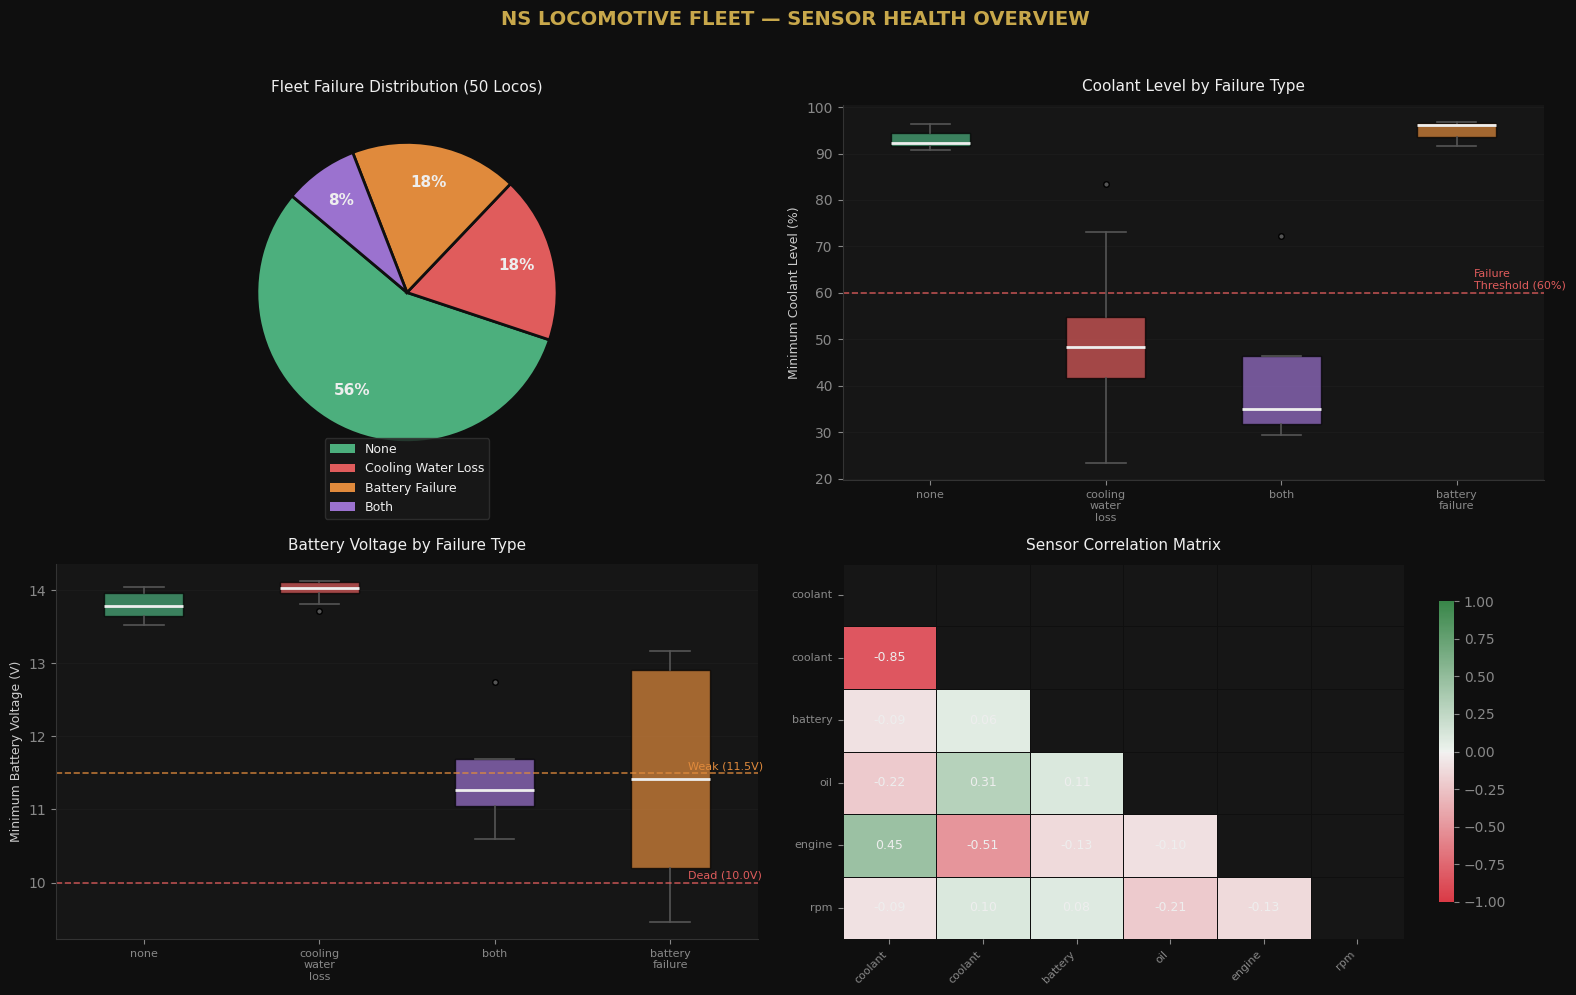

Correlation Matrix:
  coolant_level_pct    ↔ coolant_temp_f        r = -0.85
  engine_temp_f        ↔ coolant_level_pct     r = -0.51

Highly correlated sensors may be redundant features — we'll revisit this in preprocessing.


In [ ]:
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Plot styling
plt.rcParams.update({
    'figure.facecolor':  '#0F0F0F',
    'axes.facecolor':    '#161616',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   '#CCCCCC',
    'axes.titlecolor':   '#EEEEEE',
    'xtick.color':       '#888888',
    'ytick.color':       '#888888',
    'grid.color':        '#252525',
    'text.color':        '#CCCCCC',
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

#Color palette
GOLD   = '#C8A84B'
RED    = '#E05C5C'
BLUE   = '#5B9BD5'
GREEN  = '#4CAF7D'
ORANGE = '#E08A3C'
PURPLE = '#9B72CF'
WHITE  = '#EEEEEE'
palette = {
    'none': GREEN,
    'cooling_water_loss': RED,
    'battery_failure': ORANGE,
    'both': PURPLE
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NS LOCOMOTIVE FLEET — SENSOR HEALTH OVERVIEW',
             fontsize=14, fontweight='bold', color=GOLD, y=0.99)

# failure distribution pie chart
ax = axes[0, 0]
counts = fleet['failure_types'].value_counts()
colors = [palette[k] for k in counts.index]
wedges, texts, autotexts = ax.pie(
    counts, colors=colors, autopct='%1.0f%%', startangle=140,
    pctdistance=0.75, wedgeprops={'edgecolor': '#0F0F0F', 'linewidth': 2}
)
for at in autotexts:
    at.set_color(WHITE); at.set_fontsize(11); at.set_fontweight('bold')

legend_elements = [mpatches.Patch(facecolor=palette[k], label=k.replace('_',' ').title())
                   for k in counts.index]
ax.legend(handles=legend_elements, loc='lower center', fontsize=9,
          facecolor='#1A1A1A', edgecolor='#333', labelcolor=WHITE,
          bbox_to_anchor=(0.5, -0.12))
ax.set_title('Fleet Failure Distribution (50 Locos)', fontsize=11, color=WHITE, pad=10)

# boxplot: min coolant level by failure type
ax = axes[0, 1]
order = [o for o in ['none','cooling_water_loss','both','battery_failure']
         if o in fleet['failure_types'].unique()]
data = [fleet[fleet['failure_types']==ft]['min_coolant_level'].values for ft in order]
bp = ax.boxplot(data, patch_artist=True,
                medianprops={'color': WHITE, 'linewidth': 2},
                whiskerprops={'color': '#555', 'linewidth': 1.2},
                capprops={'color': '#555', 'linewidth': 1.2},
                flierprops={'marker':'o','markerfacecolor':'#555','markersize':4})
for patch, ft in zip(bp['boxes'], order):
    patch.set_facecolor(palette[ft]); patch.set_alpha(0.7)
ax.axhline(60, color=RED, linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(len(order)+0.1, 61, 'Failure\nThreshold (60%)', color=RED, fontsize=8)
ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels([o.replace('_','\n') for o in order], fontsize=8)
ax.set_ylabel('Minimum Coolant Level (%)', fontsize=9)
ax.set_title('Coolant Level by Failure Type', fontsize=11, color=WHITE, pad=10)
ax.grid(axis='y', alpha=0.4)

# Boxplot: min battery voltage by failure type 
ax = axes[1, 0]
data_bat = [fleet[fleet['failure_types']==ft]['min_battery_volts'].values for ft in order]
bp2 = ax.boxplot(data_bat, patch_artist=True,
                 medianprops={'color': WHITE, 'linewidth': 2},
                 whiskerprops={'color': '#555', 'linewidth': 1.2},
                 capprops={'color': '#555', 'linewidth': 1.2},
                 flierprops={'marker':'o','markerfacecolor':'#555','markersize':4})
for patch, ft in zip(bp2['boxes'], order):
    patch.set_facecolor(palette[ft]); patch.set_alpha(0.7)
ax.axhline(11.5, color=ORANGE, linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(len(order)+0.1, 11.55, 'Weak (11.5V)', color=ORANGE, fontsize=8)
ax.axhline(10.0, color=RED, linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(len(order)+0.1, 10.05, 'Dead (10.0V)', color=RED, fontsize=8)
ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels([o.replace('_','\n') for o in order], fontsize=8)
ax.set_ylabel('Minimum Battery Voltage (V)', fontsize=9)
ax.set_title('Battery Voltage by Failure Type', fontsize=11, color=WHITE, pad=10)
ax.grid(axis='y', alpha=0.4)

#Heatmap: sensor correlations
ax = axes[1, 1]
sensor_cols = ['coolant_temp_f','coolant_level_pct','battery_volts',
               'oil_pressure_psi','engine_temp_f','rpm']
corr = df[sensor_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(10,133,as_cmap=True),
            vmax=1, vmin=-1, center=0, annot=True, fmt='.2f',
            annot_kws={'size':9,'color':WHITE},
            linewidths=0.5, linecolor='#0F0F0F',
            cbar_kws={'shrink':0.8}, ax=ax)
ax.set_xticklabels([s.split('_')[0] for s in sensor_cols], fontsize=8, rotation=45, ha='right')
ax.set_yticklabels([s.split('_')[0] for s in sensor_cols], fontsize=8, rotation=0)
ax.set_title('Sensor Correlation Matrix', fontsize=11, color=WHITE, pad=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# KEY INSIGHT
print('Correlation Matrix:')
high_corr = [(sensor_cols[i], sensor_cols[j], round(corr.iloc[i,j],2))
             for i in range(len(sensor_cols))
             for j in range(i)
             if abs(corr.iloc[i,j]) > 0.5]
for a, b, v in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f'  {a:20s} <-> {b:20s}  r = {v}')
print('\nHighly correlated sensors may be redundant features — we\'ll revisit this in preprocessing.')